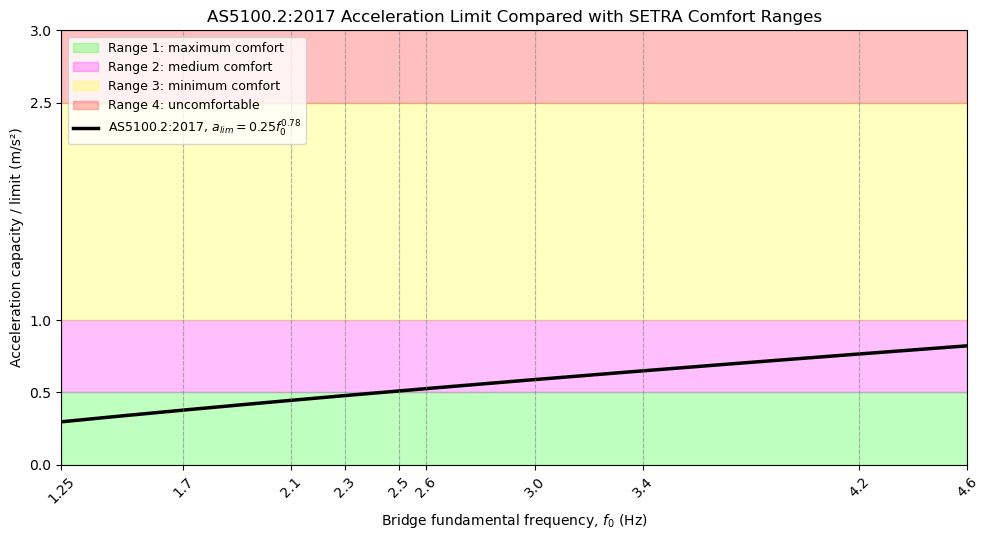

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# FREQUENCY RANGE
# ==================================================
f_min = 1.25
f_max = 4.60

f = np.linspace(f_min, f_max, 500)

# ==================================================
# AS5100.2:2017 CAPACITY LINE
# a_lim = 0.25 f0^0.78
# ==================================================
a_as5100 = 0.25 * f**0.78

# ==================================================
# SETRA ACCELERATION RANGES
# Based on the ranges in your figure:
# Range 1: 0.0 - 0.5
# Range 2: 0.5 - 1.0
# Range 3: 1.0 - 2.5
# Range 4: > 2.5
# ==================================================
setra_ranges = [
    (0.0, 0.5, "Range 1: maximum comfort", "lime"),
    (0.5, 1.0, "Range 2: medium comfort", "magenta"),
    (1.0, 2.5, "Range 3: minimum comfort", "yellow"),
    (2.5, 3.0, "Range 4: uncomfortable", "red"),
]

# ==================================================
# PLOT
# ==================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

# SETRA horizontal bands
for y1, y2, label, color in setra_ranges:
    ax.axhspan(
        y1, y2,
        color=color,
        alpha=0.25,
        label=label
    )

# AS5100 capacity line
ax.plot(
    f,
    a_as5100,
    color="black",
    linewidth=2.5,
    label=r"AS5100.2:2017, $a_{lim}=0.25 f_0^{0.78}$"
)

# Frequency markers you commonly use
vertical_markers = [1.25, 1.70, 2.10, 2.30, 2.50, 2.60, 3.00, 3.40, 4.20, 4.60]

for x in vertical_markers:
    ax.axvline(x, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

# Labels
ax.set_xlabel("Bridge fundamental frequency, $f_0$ (Hz)")
ax.set_ylabel("Acceleration capacity / limit (m/s²)")
ax.set_title("AS5100.2:2017 Acceleration Limit Compared with SETRA Comfort Ranges")

# Limits
ax.set_xlim(f_min, f_max)
ax.set_ylim(0.0, 3.0)

# Ticks
ax.set_xticks(vertical_markers)
ax.set_xticklabels([str(x) for x in vertical_markers], rotation=45)
ax.set_yticks([0.0, 0.5, 1.0, 2.5, 3.0])

ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

Structural damping ratio, zeta = 0.005
Logarithmic decrement, delta = 0.031416319242342894
Span = 50.0 m
Actual delta = 0.031416319242342894
Delta used in graph = 0.031416319242342894
Selected dynamic response factor psi = 14.902572959107992


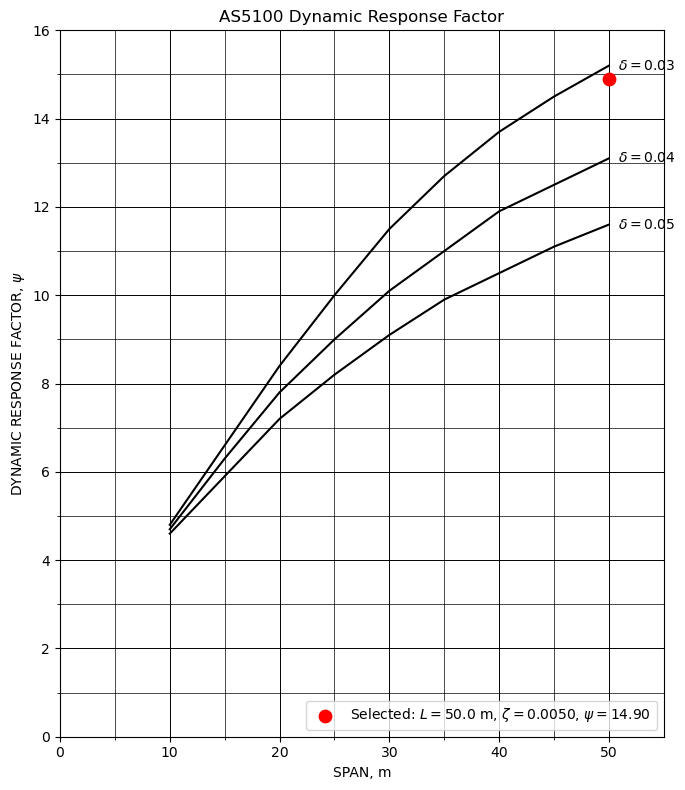

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ==================================================
# USER INPUTS
# ==================================================

Length = 50.0       # bridge span in m
zeta = 0.005        # structural damping ratio, e.g. 0.005 = 0.5%

# ==================================================
# CONVERT DAMPING RATIO TO LOGARITHMIC DECREMENT
# ==================================================

def damping_ratio_to_log_decrement(zeta):
    """
    Exact relation:
        delta = 2*pi*zeta / sqrt(1 - zeta^2)

    For small damping:
        delta ≈ 2*pi*zeta
    """
    return (2.0 * math.pi * zeta) / math.sqrt(1.0 - zeta**2)


delta_selected = damping_ratio_to_log_decrement(zeta)

print("Structural damping ratio, zeta =", zeta)
print("Logarithmic decrement, delta =", delta_selected)

# ==================================================
# APPROXIMATE DIGITISED AS5100 FIGURE DATA
# From Figure 13.4.2 style graph
# x-axis: span, m
# y-axis: dynamic response factor psi
# ==================================================

span_points = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50], dtype=float)

# Curves for logarithmic decrement delta
psi_delta_003 = np.array([4.8, 6.6, 8.4, 10.0, 11.5, 12.7, 13.7, 14.5, 15.2])
psi_delta_004 = np.array([4.7, 6.3, 7.8, 9.0, 10.1, 11.0, 11.9, 12.5, 13.1])
psi_delta_005 = np.array([4.6, 5.9, 7.2, 8.2, 9.1, 9.9, 10.5, 11.1, 11.6])

delta_curves = np.array([0.03, 0.04, 0.05])

psi_curves = np.vstack([
    psi_delta_003,
    psi_delta_004,
    psi_delta_005
])

# ==================================================
# INTERPOLATE PSI FOR GIVEN SPAN AND DAMPING RATIO
# ==================================================

def psi_from_span_and_zeta(span, zeta, clamp_delta=True):
    """
    Calculates AS5100 dynamic response factor psi.

    Step 1:
        zeta -> logarithmic decrement delta

    Step 2:
        interpolate psi from span and delta curves.

    Note:
        The figure only gives delta = 0.03, 0.04, 0.05.
        If clamp_delta=True, values outside this range are clipped.
    """

    delta = damping_ratio_to_log_decrement(zeta)

    # interpolate each curve at the required span
    psi_at_span = np.array([
        np.interp(span, span_points, psi_delta_003),
        np.interp(span, span_points, psi_delta_004),
        np.interp(span, span_points, psi_delta_005)
    ])

    if clamp_delta:
        delta_used = np.clip(delta, delta_curves.min(), delta_curves.max())
    else:
        delta_used = delta

    # interpolate between delta curves
    psi = np.interp(delta_used, delta_curves, psi_at_span)

    return psi, delta, delta_used


psi_selected, delta_actual, delta_used = psi_from_span_and_zeta(
    span=Length,
    zeta=zeta,
    clamp_delta=True
)

print("Span =", Length, "m")
print("Actual delta =", delta_actual)
print("Delta used in graph =", delta_used)
print("Selected dynamic response factor psi =", psi_selected)

# ==================================================
# PLOT AS5100 DYNAMIC RESPONSE FACTOR GRAPH
# ==================================================

plt.figure(figsize=(7, 8))

# Plot curves
plt.plot(span_points, psi_delta_003, color="black", linewidth=1.5)
plt.plot(span_points, psi_delta_004, color="black", linewidth=1.5)
plt.plot(span_points, psi_delta_005, color="black", linewidth=1.5)

# Mark selected point
plt.scatter(
    Length,
    psi_selected,
    s=80,
    color="red",
    zorder=5,
    label=rf"Selected: $L={Length:.1f}$ m, $\zeta={zeta:.4f}$, $\psi={psi_selected:.2f}$"
)

# Curve labels on the right
plt.text(50.8, psi_delta_003[-1], r"$\delta=0.03$", va="center")
plt.text(50.8, psi_delta_004[-1], r"$\delta=0.04$", va="center")
plt.text(50.8, psi_delta_005[-1], r"$\delta=0.05$", va="center")

# Axes limits
plt.xlim(0, 55)
plt.ylim(0, 16)

# Grid similar to the figure
plt.xticks(np.arange(0, 55, 10))
plt.yticks(np.arange(0, 17, 2))

plt.gca().set_xticks(np.arange(0, 55, 5), minor=True)
plt.gca().set_yticks(np.arange(0, 17, 1), minor=True)

plt.grid(which="major", color="black", linewidth=0.7)
plt.grid(which="minor", color="black", linewidth=0.5)

# Labels
plt.xlabel("SPAN, m")
plt.ylabel(r"DYNAMIC RESPONSE FACTOR, $\psi$")

plt.title("AS5100 Dynamic Response Factor")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

AS5100 SIMPLIFIED ACCELERATION FOR GIVEN BRIDGE
Span, L                         = 50.0 m
Bridge frequency, f0             = 2.25 Hz
Damping ratio, zeta              = 0.005
Logarithmic decrement, delta     = 0.031416319242342894
Delta used in AS5100 psi curve   = 0.031416319242342894
Dynamic response factor, psi     = 14.902572959107992
Load case                        = 700 N point load at midspan
EI                               = 6411731152.366686 N.m²
Static displacement, y           = 0.00028430959180092804 m
AS5100 acceleration demand, a    = 0.8467935501751912 m/s²
AS5100 acceleration capacity     = 0.470589651722238 m/s²
Utilisation = demand / capacity  = 1.7994308779977268


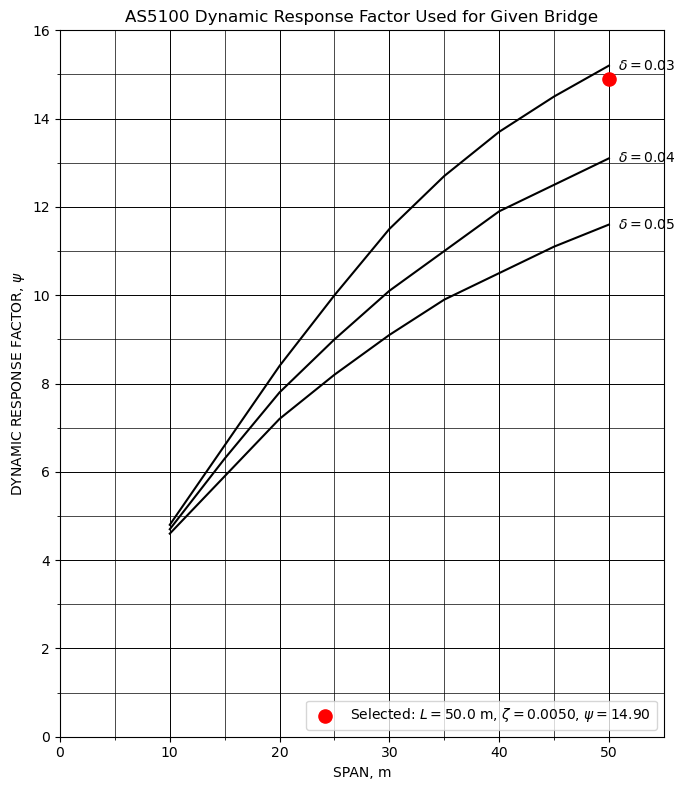

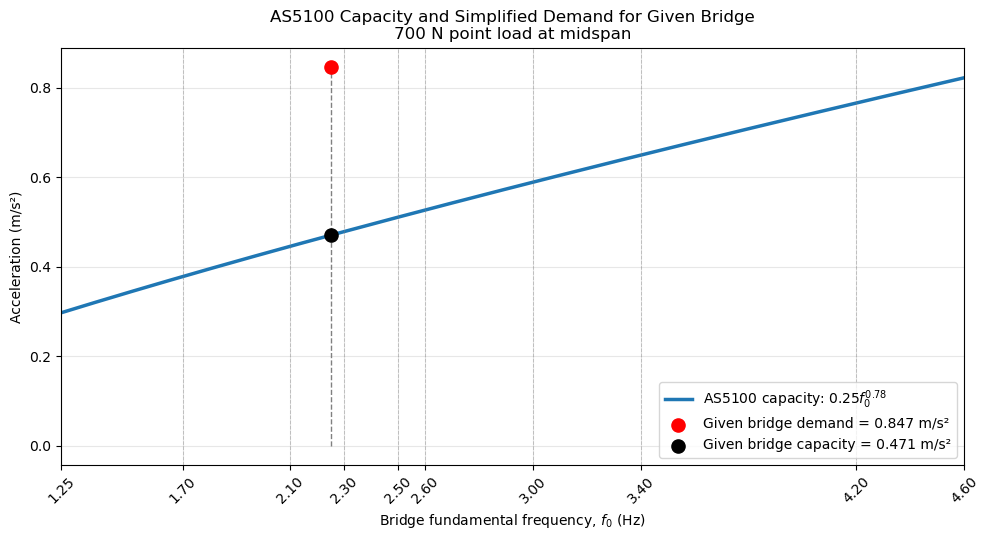

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ==================================================
# GIVEN BRIDGE INPUTS
# ==================================================

Length = 50.0          # m
linearMass = 500.0     # kg/m

BeamFreq = 2.25        # Hz, or use your actual bridge frequency
Beamdamp = 0.005       # damping ratio zeta, e.g. 0.005 = 0.5%

P = 700.0              # N, AS5100 design pedestrian load

load_type = "point"    # "point", "udl_total", or "udl_intensity"
w_custom = None        # only for load_type = "udl_intensity"

# Frequency range only for plotting capacity
f_min = 1.25
f_max = 4.60
num_points = 500


# ==================================================
# AS5100 FIGURE 13.4.2 APPROXIMATE PSI DATA
# x-axis: span
# curves: logarithmic decrement delta = 0.03, 0.04, 0.05
# ==================================================

span_points = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50], dtype=float)

psi_delta_003 = np.array([4.8, 6.6, 8.4, 10.0, 11.5, 12.7, 13.7, 14.5, 15.2])
psi_delta_004 = np.array([4.7, 6.3, 7.8, 9.0, 10.1, 11.0, 11.9, 12.5, 13.1])
psi_delta_005 = np.array([4.6, 5.9, 7.2, 8.2, 9.1, 9.9, 10.5, 11.1, 11.6])

delta_curves = np.array([0.03, 0.04, 0.05])


# ==================================================
# FUNCTIONS
# ==================================================

def get_first_frequency(BeamFreq):
    """Return first bridge frequency from scalar/list/array."""
    if np.ndim(BeamFreq) > 0:
        return float(np.asarray(BeamFreq).ravel()[0])
    return float(BeamFreq)


def damping_ratio_to_log_decrement(zeta):
    """
    Exact relation:

        delta = 2*pi*zeta / sqrt(1 - zeta^2)
    """
    zeta = float(zeta)

    if zeta <= 0:
        raise ValueError("Damping ratio must be positive.")

    if zeta >= 1:
        raise ValueError("This relation is for underdamped systems only, zeta < 1.")

    return (2.0 * math.pi * zeta) / math.sqrt(1.0 - zeta**2)


def log_decrement_to_damping_ratio(delta):
    """
    Inverse relation:

        zeta = delta / sqrt(4*pi^2 + delta^2)
    """
    return delta / math.sqrt(4.0 * math.pi**2 + delta**2)


def psi_from_span_and_zeta(span, zeta, clamp_delta=True):
    """
    Get AS5100 dynamic response factor psi from:

        bridge damping ratio zeta
        -> logarithmic decrement delta
        -> AS5100 Figure 13.4.2 psi curve
    """

    delta_actual = damping_ratio_to_log_decrement(zeta)

    # Interpolate each delta curve at required span
    psi_at_span_delta_003 = np.interp(span, span_points, psi_delta_003)
    psi_at_span_delta_004 = np.interp(span, span_points, psi_delta_004)
    psi_at_span_delta_005 = np.interp(span, span_points, psi_delta_005)

    psi_at_span = np.array([
        psi_at_span_delta_003,
        psi_at_span_delta_004,
        psi_at_span_delta_005
    ])

    if clamp_delta:
        delta_used = np.clip(delta_actual, delta_curves.min(), delta_curves.max())
    else:
        delta_used = delta_actual

    # Interpolate between delta curves
    psi = np.interp(delta_used, delta_curves, psi_at_span)

    return psi, delta_actual, delta_used


def EI_from_frequency(f, Length, linearMass):
    """
    For simply supported beam:

        omega = (pi/L)^2 * sqrt(EI/m)

    Therefore:

        EI = m * [omega / (pi/L)^2]^2
    """
    omega = 2.0 * math.pi * f
    EI = linearMass * (omega * (math.pi / Length) ** (-2)) ** 2
    return EI


def static_displacement_midspan(Length, EI, load_type="point", P=700.0, w=None):
    """
    Static midspan displacement.

    point:
        700 N point load at midspan
        y = P L^3 / (48 EI)

    udl_total:
        total 700 N distributed over span
        w = P/L
        y = 5 w L^4 / (384 EI)

    udl_intensity:
        custom UDL intensity w in N/m
        y = 5 w L^4 / (384 EI)
    """

    if load_type == "point":
        y_static = P * Length**3 / (48.0 * EI)
        load_label = "700 N point load at midspan"

    elif load_type == "udl_total":
        w_used = P / Length
        y_static = 5.0 * w_used * Length**4 / (384.0 * EI)
        load_label = "total 700 N distributed over span"

    elif load_type == "udl_intensity":
        if w is None:
            raise ValueError("For load_type='udl_intensity', provide w in N/m.")

        w_used = float(w)
        y_static = 5.0 * w_used * Length**4 / (384.0 * EI)
        load_label = f"UDL intensity = {w_used:.3f} N/m"

    else:
        raise ValueError("load_type must be 'point', 'udl_total', or 'udl_intensity'.")

    return y_static, load_label


def as5100_capacity(f):
    """
    AS5100 acceleration limit:

        a_lim = 0.25 f0^0.78
    """
    return 0.25 * f**0.78


def as5100_simplified_demand(f, y_static, psi):
    """
    AS5100 simplified acceleration:

        a = 4*pi^2*f^2*y*psi
    """
    return 4.0 * math.pi**2 * f**2 * y_static * psi


# ==================================================
# CALCULATE GIVEN BRIDGE ACCELERATION
# ==================================================

f0 = get_first_frequency(BeamFreq)
zeta = float(Beamdamp)

psi, delta_actual, delta_used = psi_from_span_and_zeta(
    span=Length,
    zeta=zeta,
    clamp_delta=True
)

EI = EI_from_frequency(
    f=f0,
    Length=Length,
    linearMass=linearMass
)

y_static, load_label = static_displacement_midspan(
    Length=Length,
    EI=EI,
    load_type=load_type,
    P=P,
    w=w_custom
)

a_demand = as5100_simplified_demand(
    f=f0,
    y_static=y_static,
    psi=psi
)

a_capacity = as5100_capacity(f0)

utilisation = a_demand / a_capacity


# ==================================================
# PRINT RESULTS
# ==================================================

print("==================================================")
print("AS5100 SIMPLIFIED ACCELERATION FOR GIVEN BRIDGE")
print("==================================================")
print("Span, L                         =", Length, "m")
print("Bridge frequency, f0             =", f0, "Hz")
print("Damping ratio, zeta              =", zeta)
print("Logarithmic decrement, delta     =", delta_actual)
print("Delta used in AS5100 psi curve   =", delta_used)
print("Dynamic response factor, psi     =", psi)
print("Load case                        =", load_label)
print("EI                               =", EI, "N.m²")
print("Static displacement, y           =", y_static, "m")
print("AS5100 acceleration demand, a    =", a_demand, "m/s²")
print("AS5100 acceleration capacity     =", a_capacity, "m/s²")
print("Utilisation = demand / capacity  =", utilisation)

if abs(delta_actual - delta_used) > 1e-12:
    print("\nWARNING:")
    print("Your damping ratio gives a logarithmic decrement outside the plotted AS5100 range.")
    print("The value was clamped to the nearest available curve.")


# ==================================================
# PLOT 1: AS5100 PSI GRAPH WITH SELECTED POINT
# ==================================================

plt.figure(figsize=(7, 8))

plt.plot(span_points, psi_delta_003, color="black", linewidth=1.5)
plt.plot(span_points, psi_delta_004, color="black", linewidth=1.5)
plt.plot(span_points, psi_delta_005, color="black", linewidth=1.5)

plt.scatter(
    Length,
    psi,
    s=90,
    color="red",
    zorder=5,
    label=rf"Selected: $L={Length:.1f}$ m, $\zeta={zeta:.4f}$, $\psi={psi:.2f}$"
)

plt.text(50.8, psi_delta_003[-1], r"$\delta=0.03$", va="center")
plt.text(50.8, psi_delta_004[-1], r"$\delta=0.04$", va="center")
plt.text(50.8, psi_delta_005[-1], r"$\delta=0.05$", va="center")

plt.xlim(0, 55)
plt.ylim(0, 16)

plt.xticks(np.arange(0, 55, 10))
plt.yticks(np.arange(0, 17, 2))

plt.gca().set_xticks(np.arange(0, 55, 5), minor=True)
plt.gca().set_yticks(np.arange(0, 17, 1), minor=True)

plt.grid(which="major", color="black", linewidth=0.7)
plt.grid(which="minor", color="black", linewidth=0.5)

plt.xlabel("SPAN, m")
plt.ylabel(r"DYNAMIC RESPONSE FACTOR, $\psi$")
plt.title("AS5100 Dynamic Response Factor Used for Given Bridge")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# ==================================================
# PLOT 2: AS5100 CAPACITY LINE AND GIVEN BRIDGE DEMAND
# ==================================================

frequencies = np.linspace(f_min, f_max, num_points)
capacity_curve = as5100_capacity(frequencies)

plt.figure(figsize=(10, 5.5))

plt.plot(
    frequencies,
    capacity_curve,
    linewidth=2.5,
    label=r"AS5100 capacity: $0.25 f_0^{0.78}$"
)

plt.scatter(
    f0,
    a_demand,
    s=90,
    color="red",
    zorder=5,
    label=rf"Given bridge demand = {a_demand:.3f} m/s²"
)

plt.scatter(
    f0,
    a_capacity,
    s=90,
    color="black",
    zorder=5,
    label=rf"Given bridge capacity = {a_capacity:.3f} m/s²"
)

plt.vlines(
    f0,
    ymin=0,
    ymax=max(a_demand, a_capacity),
    color="gray",
    linestyle="--",
    linewidth=1.0
)

vertical_markers = [1.25, 1.70, 2.10, 2.30, 2.50, 2.60, 3.00, 3.40, 4.20, 4.60]

for x in vertical_markers:
    plt.axvline(x, color="gray", linestyle="--", linewidth=0.7, alpha=0.4)

plt.xlabel("Bridge fundamental frequency, $f_0$ (Hz)")
plt.ylabel("Acceleration (m/s²)")
plt.title(f"AS5100 Capacity and Simplified Demand for Given Bridge\n{load_label}")

plt.xlim(f_min, f_max)
plt.xticks(vertical_markers, rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

AS5100 PSI SELECTION
Span L                         = 50.0 m
Damping ratio zeta             = 0.005
Logarithmic decrement delta    = 0.031416319242342894
Delta used in AS5100 graph     = 0.031416319242342894
Dynamic response factor psi    = 14.902572959107992

LOAD CASE
700 N point load at midspan

FIRST FEW RESULTS
   frequency_Hz        EI_Nm2  y_static_m        psi  demand_mps2  \
0      1.250000  1.978929e+09    0.000921  14.902573     0.846794   
1      1.256713  2.000243e+09    0.000911  14.902573     0.846794   
2      1.263427  2.021671e+09    0.000902  14.902573     0.846794   
3      1.270140  2.043213e+09    0.000892  14.902573     0.846794   
4      1.276854  2.064869e+09    0.000883  14.902573     0.846794   

   capacity_mps2  utilisation  
0       0.297529     2.846084  
1       0.298775     2.834218  
2       0.300019     2.822464  
3       0.301262     2.810821  
4       0.302503     2.799287  


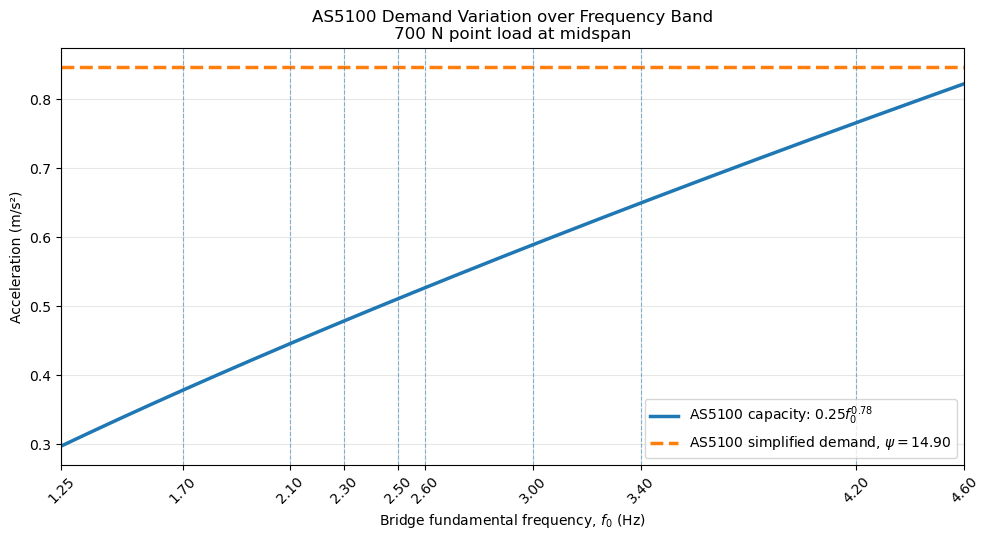

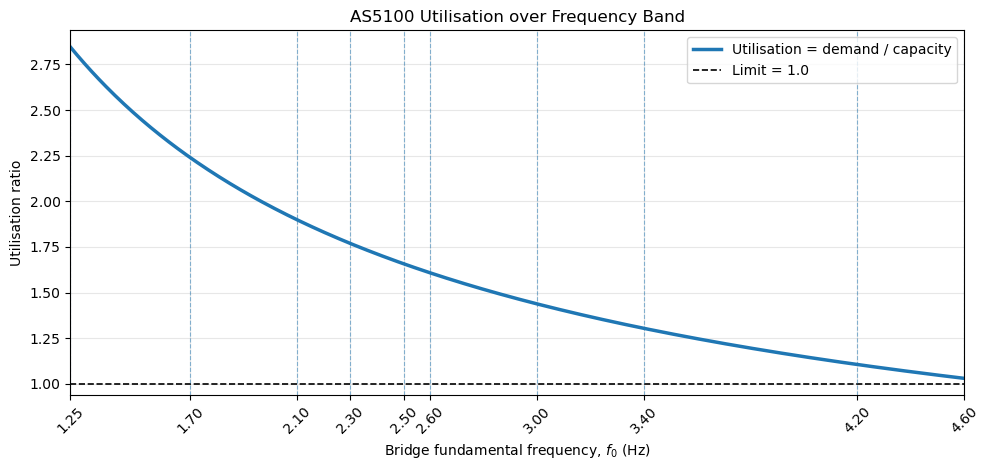

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ==================================================
# USER INPUTS
# ==================================================

Length = 50.0          # span, m
linearMass = 500.0     # kg/m
Beamdamp = 0.005       # damping ratio zeta

P = 700.0              # N, AS5100 design pedestrian load

load_type = "point"    # "point", "udl_total", or "udl_intensity"
w_custom = None        # N/m, only used if load_type = "udl_intensity"

f_min = 1.25
f_max = 4.60
num_points = 500

# ==================================================
# AS5100 FIGURE 13.4.2 APPROXIMATE PSI DATA
# span in m, psi from logarithmic decrement curves
# ==================================================

span_points = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50], dtype=float)

psi_delta_003 = np.array([4.8, 6.6, 8.4, 10.0, 11.5, 12.7, 13.7, 14.5, 15.2])
psi_delta_004 = np.array([4.7, 6.3, 7.8, 9.0, 10.1, 11.0, 11.9, 12.5, 13.1])
psi_delta_005 = np.array([4.6, 5.9, 7.2, 8.2, 9.1, 9.9, 10.5, 11.1, 11.6])

delta_curves = np.array([0.03, 0.04, 0.05])


# ==================================================
# FUNCTIONS
# ==================================================

def damping_ratio_to_log_decrement(zeta):
    """
    Convert damping ratio to logarithmic decrement.
    """
    zeta = float(zeta)

    if zeta <= 0:
        raise ValueError("Damping ratio must be positive.")

    if zeta >= 1:
        raise ValueError("This is for underdamped systems only, zeta < 1.")

    return (2.0 * math.pi * zeta) / math.sqrt(1.0 - zeta**2)


def psi_from_span_and_zeta(span, zeta, clamp_delta=True):
    """
    Get AS5100 dynamic response factor psi from span and damping ratio.
    """

    delta_actual = damping_ratio_to_log_decrement(zeta)

    psi_at_span = np.array([
        np.interp(span, span_points, psi_delta_003),
        np.interp(span, span_points, psi_delta_004),
        np.interp(span, span_points, psi_delta_005)
    ])

    if clamp_delta:
        delta_used = np.clip(delta_actual, delta_curves.min(), delta_curves.max())
    else:
        delta_used = delta_actual

    psi = np.interp(delta_used, delta_curves, psi_at_span)

    return psi, delta_actual, delta_used


def EI_from_frequency(f, Length, linearMass):
    """
    Back-calculate EI from simply supported first-mode frequency.

    omega = (pi/L)^2 * sqrt(EI/m)
    """
    omega = 2.0 * math.pi * f
    EI = linearMass * (omega * (math.pi / Length) ** (-2)) ** 2
    return EI


def static_displacement_midspan(Length, EI, load_type="point", P=700.0, w=None):
    """
    Static displacement y at midspan.

    point:
        y = P L^3 / (48 EI)

    udl_total:
        total 700 N spread over full span

    udl_intensity:
        custom UDL intensity in N/m
    """

    if load_type == "point":
        y_static = P * Length**3 / (48.0 * EI)
        load_label = "700 N point load at midspan"

    elif load_type == "udl_total":
        w_used = P / Length
        y_static = 5.0 * w_used * Length**4 / (384.0 * EI)
        load_label = "total 700 N distributed over span"

    elif load_type == "udl_intensity":
        if w is None:
            raise ValueError("For load_type='udl_intensity', give w_custom in N/m.")

        w_used = float(w)
        y_static = 5.0 * w_used * Length**4 / (384.0 * EI)
        load_label = f"UDL intensity = {w_used:.3f} N/m"

    else:
        raise ValueError("load_type must be 'point', 'udl_total', or 'udl_intensity'.")

    return y_static, load_label


def as5100_capacity(f):
    """
    AS5100 acceleration capacity/limit.
    """
    return 0.25 * f**0.78


def as5100_demand(f, y_static, psi):
    """
    AS5100 simplified demand.

        a = 4*pi^2*f^2*y*psi
    """
    return 4.0 * math.pi**2 * f**2 * y_static * psi


# ==================================================
# CALCULATE PSI FROM SPAN AND DAMPING
# ==================================================

psi, delta_actual, delta_used = psi_from_span_and_zeta(
    span=Length,
    zeta=Beamdamp,
    clamp_delta=True
)

print("==================================================")
print("AS5100 PSI SELECTION")
print("==================================================")
print("Span L                         =", Length, "m")
print("Damping ratio zeta             =", Beamdamp)
print("Logarithmic decrement delta    =", delta_actual)
print("Delta used in AS5100 graph     =", delta_used)
print("Dynamic response factor psi    =", psi)

if abs(delta_actual - delta_used) > 1e-12:
    print("\nWARNING:")
    print("Your damping gives delta outside the AS5100 graph range.")
    print("The value was clamped to the nearest available curve.")


# ==================================================
# DEMAND VARIATION OVER FREQUENCY BAND
# ==================================================

frequencies = np.linspace(f_min, f_max, num_points)

rows = []

for f in frequencies:
    EI = EI_from_frequency(
        f=f,
        Length=Length,
        linearMass=linearMass
    )

    y_static, load_label = static_displacement_midspan(
        Length=Length,
        EI=EI,
        load_type=load_type,
        P=P,
        w=w_custom
    )

    demand = as5100_demand(
        f=f,
        y_static=y_static,
        psi=psi
    )

    capacity = as5100_capacity(f)

    rows.append({
        "frequency_Hz": f,
        "EI_Nm2": EI,
        "y_static_m": y_static,
        "psi": psi,
        "demand_mps2": demand,
        "capacity_mps2": capacity,
        "utilisation": demand / capacity
    })

as5100_demand_df = pd.DataFrame(rows)

print("\n==================================================")
print("LOAD CASE")
print("==================================================")
print(load_label)

print("\n==================================================")
print("FIRST FEW RESULTS")
print("==================================================")
print(as5100_demand_df.head())


# ==================================================
# PLOT: DEMAND AND CAPACITY
# ==================================================

vertical_markers = [1.25, 1.70, 2.10, 2.30, 2.50, 2.60, 3.00, 3.40, 4.20, 4.60]

plt.figure(figsize=(10, 5.5))

plt.plot(
    as5100_demand_df["frequency_Hz"],
    as5100_demand_df["capacity_mps2"],
    linewidth=2.5,
    label=r"AS5100 capacity: $0.25 f_0^{0.78}$"
)

plt.plot(
    as5100_demand_df["frequency_Hz"],
    as5100_demand_df["demand_mps2"],
    linewidth=2.5,
    linestyle="--",
    label=rf"AS5100 simplified demand, $\psi={psi:.2f}$"
)

for x in vertical_markers:
    plt.axvline(x, linestyle="--", linewidth=0.8, alpha=0.5)

plt.xlabel("Bridge fundamental frequency, $f_0$ (Hz)")
plt.ylabel("Acceleration (m/s²)")
plt.title(f"AS5100 Demand Variation over Frequency Band\n{load_label}")

plt.xlim(f_min, f_max)
plt.xticks(vertical_markers, rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT: UTILISATION
# ==================================================

plt.figure(figsize=(10, 4.8))

plt.plot(
    as5100_demand_df["frequency_Hz"],
    as5100_demand_df["utilisation"],
    linewidth=2.5,
    label="Utilisation = demand / capacity"
)

plt.axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="Limit = 1.0")

for x in vertical_markers:
    plt.axvline(x, linestyle="--", linewidth=0.8, alpha=0.5)

plt.xlabel("Bridge fundamental frequency, $f_0$ (Hz)")
plt.ylabel("Utilisation ratio")
plt.title("AS5100 Utilisation over Frequency Band")

plt.xlim(f_min, f_max)
plt.xticks(vertical_markers, rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()